# Rank-$r$ Alternating Ascent vs Rank-2 Projection (Stage-2 Stress Test)

We test binary quadratic optimization:
\[
\max_{x\in\{\pm1\}^N} f(x)=x^\top M x + w^\top x + c,
\]
where **$M\succeq 0$** is generated as a **sum of PSD matrices**.

## Compared methods
1. **Alternating ascent (rank-$r$)**: two-block updates on a sphere (multi-start).
2. **Rank-2 PSD projection + exact circle scan** (solves the rank-2 surrogate globally).

### Generation detail
To make the $v_0$ embedding meaningful, we generate  
$w = 2V^\top v_0 + \text{mismatch}\cdot\epsilon$ where $M=V^\top V$.
Set `mismatch=0` for exact consistency.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# ------------------------------
# Utilities
# ------------------------------
def make_psd_sum(N, num_terms=5, term_rank=2, seed=0):
    """M = sum_i alpha_i * (G_i^T G_i), hence PSD; rank <= num_terms*term_rank."""
    rng = np.random.default_rng(seed)
    M = np.zeros((N, N))
    alphas = rng.uniform(0.2, 1.0, size=num_terms)
    for i in range(num_terms):
        G = rng.standard_normal((term_rank, N))
        M += alphas[i] * (G.T @ G)
    return 0.5 * (M + M.T)

def make_psd_flat_spectrum(N, r=None, lam_min=0.9, lam_max=1.1, seed=0):
    """
    Create PSD M with a *flat-ish* eigen-spectrum:
      eigenvalues ~ Uniform[lam_min, lam_max].
    r controls the rank (r<=N). If r=None -> full rank N.
    """
    rng = np.random.default_rng(seed)
    if r is None:
        r = N

    # Random orthonormal basis U (N x r)
    A = rng.standard_normal((N, N))
    Q, _ = np.linalg.qr(A)          # Q is orthonormal (N x N)
    U = Q[:, :r]

    # Nearly-equal eigenvalues
    lam = rng.uniform(lam_min, lam_max, size=r)  # all positive -> PSD

    # M = U diag(lam) U^T
    M = (U * lam) @ U.T
    return 0.5 * (M + M.T)

def numeric_rank_psd(M, tol=1e-10):
    evals = np.linalg.eigvalsh(M)
    mx = float(np.max(evals))
    if mx <= 0:
        return 0, evals
    r = int(np.sum(evals > tol * mx))
    return r, evals

def eig_factor_psd(M, rank=None, tol=1e-12):
    """Return V (r x N) such that M = V^T V using eigen-decomposition."""
    evals, U = np.linalg.eigh(M)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    U = U[:, idx]
    if evals[0] <= 0:
        return np.zeros((0, M.shape[0])), np.array([])
    keep = evals > tol * float(evals[0])
    evals = evals[keep]
    U = U[:, keep]
    if rank is not None:
        evals = evals[:rank]
        U = U[:, :rank]
    V = (np.sqrt(evals)[:, None] * U.T)  # r x N
    return V, evals

def objective_f(x, M, w, c=0.0):
    return float(x @ (M @ x) + w @ x + c)

def project_rank_k_psd(M, k=2):
    """Rank-k PSD projection (truncate eigen-spectrum)."""
    evals, U = np.linalg.eigh(M)
    idx = np.argsort(evals)[::-1]
    evals = np.maximum(evals[idx], 0.0)
    U = U[:, idx]
    evals_k = evals[:k]
    U_k = U[:, :k]
    Mk = (U_k * evals_k) @ U_k.T
    return 0.5 * (Mk + Mk.T)

def sign_pm1(z):
    s = np.sign(z)
    s[s == 0] = 1.0
    return s.astype(int)

def compute_v0_ls(V, w):
    """Least-squares v0: minimize ||2 V^T v0 - w||^2."""
    # Solve (V V^T) v0 = 0.5 V w
    A = V @ V.T
    b = 0.5 * (V @ w)
    try:
        return np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(A) @ b

def generate_instance(N=128, num_terms=6, term_rank=2, seed=1, mismatch=0.05):
    """Generate PSD M, consistent w (plus mismatch noise), and random c."""
    rng = np.random.default_rng(seed)
    # M = make_psd_sum(N, num_terms=num_terms, term_rank=term_rank, seed=seed)
    M = make_psd_flat_spectrum(N, r=N, lam_min=0.9, lam_max=1.1, seed=seed)
    r, evals = numeric_rank_psd(M)
    V, _ = eig_factor_psd(M, rank=r)
    v0_true = rng.standard_normal(r)
    w = 2.0 * (V.T @ v0_true)
    if mismatch > 0:
        w = w + mismatch * rng.standard_normal(N)
    c = float(rng.standard_normal())
    return M, w, c, V, evals


## Method (1): Rank-$r$ alternating ascent (two-block updates)

We build an augmented matrix $V_{\text{aug}}=[v_0,v_1,\dots,v_N]\in\mathbb{R}^{r\times(N+1)}$.

Iterate:
1. **Sign update**: $s \leftarrow \mathrm{sgn}(V_{\text{aug}}^\top a)$
2. **Direction update**: $a \leftarrow \frac{V_{\text{aug}}s}{\|V_{\text{aug}}s\|}$

Map to RIS binary vector:
\[
x_n = s_0 s_n,\quad n=1,\dots,N.
\]


In [136]:
# ------------------------------
# Method (1): Rank-r alternating ascent (two-block updates)
# ------------------------------
def alternating_ascent_rank_r(V, w, M, c=0.0, restarts=40, max_iter=200, stable_patience=5, seed=0):
    """Two-block ascent on g(a)=sum |v_n^T a| with augmented vectors [v0, v1..vN].
    Returns best_x, best_f, history (best restart).
    """
    rng = np.random.default_rng(seed)
    r, N = V.shape
    v0 = compute_v0_ls(V, w)
    Vaug = np.column_stack([v0, V])  # r x (N+1)

    best_f = -np.inf
    best_x = None
    best_hist = None

    for rr in range(restarts):
        a = rng.standard_normal(r)
        a = a / (np.linalg.norm(a) + 1e-12)

        s_prev = None
        stable = 0

        hist_f = []
        hist_g = []

        run_best_f = -np.inf
        run_best_x = None

        for k in range(max_iter):
            # (i) sign update
            s = sign_pm1(Vaug.T @ a)  # length N+1

            if s_prev is not None and np.all(s == s_prev):
                stable += 1
            else:
                stable = 0
            s_prev = s

            # (ii) direction update
            u = Vaug @ s
            nu = np.linalg.norm(u)
            if nu < 1e-14:
                a = rng.standard_normal(r)
                a = a / (np.linalg.norm(a) + 1e-12)
                continue
            a = u / nu

            # map to x: x_n = s0 * s_n
            x = (s[0] * s[1:]).astype(int)
            fval = objective_f(x, M, w, c)
            gval = float(np.sum(np.abs(Vaug.T @ a)))

            hist_f.append(fval)
            hist_g.append(gval)

            if fval > run_best_f:
                run_best_f = fval
                run_best_x = x.copy()

            if stable >= stable_patience:
                break

        if run_best_f > best_f:
            best_f = run_best_f
            best_x = run_best_x
            best_hist = {'f': hist_f, 'g': hist_g}

    return best_x, best_f, best_hist


## Method (2): Rank-2 PSD projection + exact circle scan

1. Project $M$ to rank-2 PSD: keep top-2 eigenmodes.
2. Factor $M_{(2)} = V_2^\top V_2$ with $V_2\in\mathbb{R}^{2\times N}$.
3. Solve the rank-2 surrogate by scanning sign regions on the unit circle.


In [137]:
# ------------------------------
# Method (2): Rank-2 projection + exact circle scan
# ------------------------------
def circle_scan_rank2(V2, w, M2, c=0.0):
    """Solve rank-2 surrogate globally by scanning sign regions on the unit circle."""
    v0 = compute_v0_ls(V2, w)
    Vaug = np.column_stack([v0, V2])  # 2 x (N+1)

    angles = []
    for j in range(Vaug.shape[1]):
        vx, vy = float(Vaug[0, j]), float(Vaug[1, j])
        if abs(vx) < 1e-14 and abs(vy) < 1e-14:
            continue
        phi0 = np.arctan2(-vx, vy)
        angles.append(phi0 % (2*np.pi))
        angles.append((phi0 + np.pi) % (2*np.pi))
    angles.append(0.0)
    angles = np.array(sorted(set([float(a) for a in angles])))

    if len(angles) == 1:
        angles = np.array([0.0, 2*np.pi])

    best_f = -np.inf
    best_x = None

    for i in range(len(angles)):
        a1 = angles[i]
        a2 = angles[(i+1) % len(angles)]
        if i == len(angles) - 1:
            a2 = angles[0] + 2*np.pi
        mid = 0.5 * (a1 + a2)
        a = np.array([np.cos(mid), np.sin(mid)])
        s = sign_pm1(Vaug.T @ a)
        x = (s[0] * s[1:]).astype(int)
        fval = objective_f(x, M2, w, c)
        if fval > best_f:
            best_f = fval
            best_x = x.copy()

    return best_x, best_f


## Single trial + plots

N=80, rank(M)≈12, top-6 eigvals=[109.6644  95.5817  66.3105  55.9899  54.9323  48.3077]
Method (1)  f_full = 5908.3975
Method (2)  f_full = 5861.1182   (f_proj=5755.7068)
Random      f_full = 917.6566


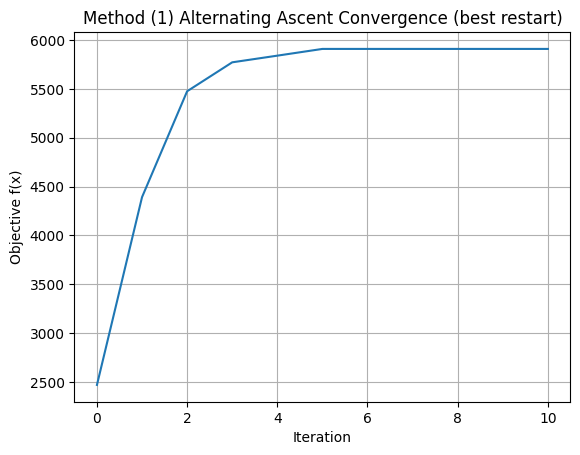

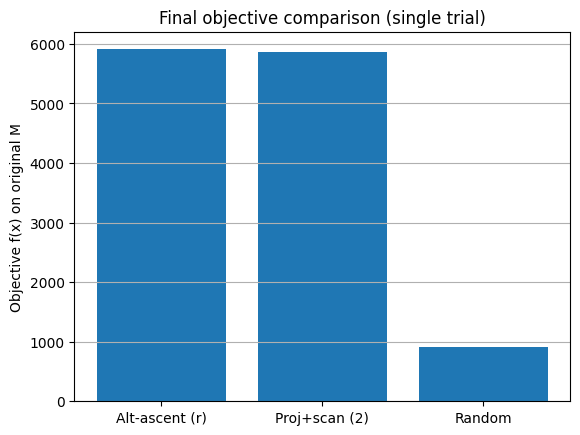

In [138]:
# ------------------------------
# Single trial + plots
# ------------------------------
N = 80
num_terms = 6
term_rank = 2
mismatch = 0

rng = np.random.default_rng()                 # uses OS entropy
seed = int(rng.integers(0, 1_000_000_000))    # new each run

M, w, c, V, evals = generate_instance(N=N, num_terms=num_terms, term_rank=term_rank, seed=seed, mismatch=mismatch)
r, _ = numeric_rank_psd(M)
print(f"N={N}, rank(M)≈{r}, top-6 eigvals={np.sort(evals)[::-1][:6]}")

# Method (1)
x1, f1, hist1 = alternating_ascent_rank_r(V, w, M, c=c, restarts=50, seed=1)

# Method (2)
M2 = project_rank_k_psd(M, k=2)
V2, _ = eig_factor_psd(M2, rank=2)
x2, f2_proj = circle_scan_rank2(V2, w, M2, c=c)
f2_full = objective_f(x2, M, w, c)

# Random baseline
rng = np.random.default_rng(123)
xrand = rng.choice([-1, 1], size=N)
frand = objective_f(xrand, M, w, c)

print(f"Method (1)  f_full = {f1:.4f}")
print(f"Method (2)  f_full = {f2_full:.4f}   (f_proj={f2_proj:.4f})")
print(f"Random      f_full = {frand:.4f}")

# Convergence plot (method 1)
plt.figure()
plt.plot(hist1['f'])
plt.xlabel('Iteration')
plt.ylabel('Objective f(x)')
plt.title('Method (1) Alternating Ascent Convergence (best restart)')
plt.grid(True)
plt.show()

# Final comparison
plt.figure()
plt.bar(['Alt-ascent (r)', 'Proj+scan (2)', 'Random'], [f1, f2_full, frand])
plt.ylabel('Objective f(x) on original M')
plt.title('Final objective comparison (single trial)')
plt.grid(True, axis='y')
plt.show()


## Monte Carlo comparison

/var/folders/5x/zg5yk1xd6dldb_th5j1sqyf00000gn/T/ipykernel_50606/203245364.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([vals_alt, vals_proj, vals_rand], labels=['Alt-ascent (r)', 'Proj+scan (2)', 'Random'])


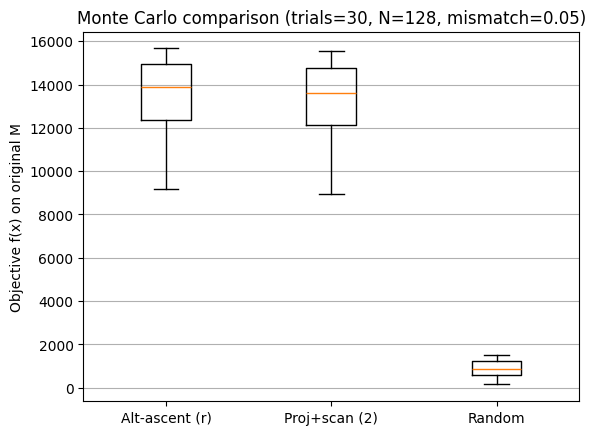

Means:
  Alt-ascent: 13523.544778826492
  Proj+scan : 13262.220095911996
  Random    : 889.9581769296739


In [139]:
# ------------------------------
# Monte Carlo comparison
# ------------------------------
trials = 30
N = 128
mismatch = 0.05
restarts = 50

vals_alt = []
vals_proj = []
vals_rand = []

rng = np.random.default_rng(2024)
for t in range(trials):
    seed = int(rng.integers(0, 1_000_000))
    M, w, c, V, evals = generate_instance(N=N, num_terms=6, term_rank=2, seed=seed, mismatch=mismatch)

    x1, f1, _ = alternating_ascent_rank_r(V, w, M, c=c, restarts=restarts, seed=seed+1)
    vals_alt.append(f1)

    M2 = project_rank_k_psd(M, k=2)
    V2, _ = eig_factor_psd(M2, rank=2)
    x2, _ = circle_scan_rank2(V2, w, M2, c=c)
    vals_proj.append(objective_f(x2, M, w, c))

    xrand = rng.choice([-1, 1], size=N)
    vals_rand.append(objective_f(xrand, M, w, c))

plt.figure()
plt.boxplot([vals_alt, vals_proj, vals_rand], labels=['Alt-ascent (r)', 'Proj+scan (2)', 'Random'])
plt.ylabel('Objective f(x) on original M')
plt.title(f'Monte Carlo comparison (trials={trials}, N={N}, mismatch={mismatch})')
plt.grid(True, axis='y')
plt.show()

print('Means:')
print('  Alt-ascent:', float(np.mean(vals_alt)))
print('  Proj+scan :', float(np.mean(vals_proj)))
print('  Random    :', float(np.mean(vals_rand)))
